## Setup

In [1]:
import sys

sys.path.insert(0, 'backend_functions')

import selection_functions as sf

import importlib

import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import xgboost as xgb

import awkward
import matplotlib.pyplot as plt
import pandas as pd

# Top is where parameters(ISRUN3) is defined!
import top 
from top import *

# Reload modules to pick up any changes
importlib.reload(sf)
from selection_functions import *

importlib.reload(top)
from top import *

import pandas as pd
import numpy as np

In [2]:
ISRUN3 = True
NUE_INTRINSIC = True

In [3]:
plots_path = parameters(ISRUN3)['plots_path']
plots_path

'/Users/abarnard/phd/ccnp/uBNuMI_CC1eNp/plots/rhc/'

In [4]:
fold = "nuselection"
tree = "NeutrinoSelectionFilter"

DATA = ""
EXT = ""
OVRLY  = ""
DRT = ""
NUE = ""

path = parameters(ISRUN3)['run4b_path']
print('path = ', path)

if not ISRUN3: 

    # Run 1 FHC 
    OVRLY = 'numi_nu_run1'
    EXT = 'neutrinoselection_filt_run1_beamoff_v5'
    DATA = 'neutrinoselection_filt_run1_beamon_beamgood_v5'
    DRT = 'prodgenie_numi_uboone_overlay_dirt_fhc_mcc9_run1_v28_all_snapshot'
    
    if NUE_INTRINSIC: 
        NUE = 'numi_nue_run1' 


else: 
 
    # Run 4 RHC
    OVRLY = 'checkout_MCC9.10_Run4b_NuMI_RHC_nu_overlay_surprise_v10_04_07_09_reco2_hist'
    DATA = 'checkout_MCC9.10_Run4b_NuMI_beam_on_RHC_data_surprise_v10_04_07_09_reco2_hist'
    EXT = 'checkout_MCC9.10_Run4b_NuMI_beam_off_RHC_data_surprise_v10_04_07_09_reco2_hist'
    # DRT = 'neutrinoselection_filt_run3b_dirt_overlay_v6'
    
    if NUE_INTRINSIC: 
        NUE = 'checkout_MCC9.10_Run4b_NuMI_RHC_nue_overlay_surprise_v10_04_07_09_reco2_hist'


path =  /pnfs/uboone/persistent/users/uboonepro/surprise/run4b_full_samples/wc_processed/NuMI/


In [5]:
overlay = uproot.open(path+OVRLY+".root")[fold][tree]
data = uproot.open(path+DATA+".root")[fold][tree]
ext = uproot.open(path+EXT+".root")[fold][tree]
# dirt = uproot.open(path+DRT+".root")[fold][tree]  

# uproot_v = [overlay,data,ext,dirt]
uproot_v = [overlay,data,ext]

if NUE_INTRINSIC: 
    nue = uproot.open(path+NUE+".root")[fold][tree]
    uproot_v.append(nue)


In [6]:
variables = [
    "trk_score_v", 
    "shr_tkfit_dedx_Y", 
    "n_tracks_contained", 
    "NeutrinoEnergy2",
    "run","sub","evt",
    "reco_nu_vtx_sce_x","reco_nu_vtx_sce_y","reco_nu_vtx_sce_z",
    "shrsubclusters0","shrsubclusters1","shrsubclusters2",
    "trkshrhitdist2",
    "n_showers_contained", 
    "shr_phi", "trk_phi", "trk_theta",
    "shr_score", 
    "trk_energy", 
    "tksh_distance", "tksh_angle",
    "shr_energy_tot_cali", "shr_energy_cali", 
    "nslice", 
    "contained_fraction",
    "shrmoliereavg", "shr_px", "shr_py", "shr_pz","swtrig_pre", "slice_orig_pass_id",
    # NuGraph slice hit counts (can use these as normal variables)
    "slcng2mip", "slcng2hip", "slcng2shr", "slcng2mcl", "slcng2dfs",
    # NuGraph clustered hit counts
    "clung2mip", "clung2hip", "clung2shr", "clung2mcl", "clung2dfs",
    # Number of HIP-labeled hits within 1/3/5/10 cm of neutrino vertex
    "ng2hip_r1cm", "ng2hip_r10cm",
    # More dE/dx variables
    "shr_tkfit_gap10_dedx_Y", "shr_tkfit_2cm_dedx_Y",
]

# MC only variables
mc_var = ["nu_pdg", "shr_theta", "true_e_visible", "ccnc", "interaction", 
          "nproton", "nu_e", "npi0", "npion",
          "true_nu_vtx_x", "true_nu_vtx_y" , "true_nu_vtx_z", 
          "weightTune", "weightSpline", "weightSplineTimesTune", 
          "true_nu_px", "true_nu_py", "true_nu_pz", 
          "elec_e", "proton_e", "mc_px", "mc_py", "mc_pz", "elec_px", "elec_py", "elec_pz", 
           "ppfx_cv", "mc_pdg"]#, "opening_angle"]


## Create pandas dataframes

In [7]:
# OVERLAY 
# Check if overlay is already a DataFrame (in case this cell was run out of order)
if isinstance(overlay, pd.DataFrame):
    print(f"Overlay entries: {len(overlay):,}")
    print("Note: overlay is already a DataFrame (cell may have been run out of order)")
else:
    # Convert from uproot object to DataFrame
    overlay = pd.DataFrame(overlay.arrays(variables + mc_var, library="np"))
    print(f"Overlay entries: {len(overlay):,}")

Overlay entries: 612,983


In [8]:
# DIRT 
# dirt = dirt.pandas.df(variables + mc_var, flatten=False)

In [9]:
# INTRINSIC 
if NUE_INTRINSIC: 
    nue = pd.DataFrame(nue.arrays(variables + mc_var, library="pd"))

In [10]:
# draw_root_like(nue['ppfx_cv'], bins='auto', xlabel='ppfx_cv', title='ppfx_cv (nue)', logy=False)

In [11]:
# BEAM ON 
data = pd.DataFrame(data.arrays(variables, library="np"))

In [12]:
# BEAM OFF
ext = pd.DataFrame(ext.arrays(variables, library="pd"))

In [13]:
# equalize the columns

for var in mc_var: 
    data[var] = np.nan
    ext[var] = np.nan

In [14]:
# is dirt bool

overlay['isDirt'] = False
# dirt['isDirt'] = True

if NUE_INTRINSIC: 
    nue['isDirt'] = False
    
data['isDirt'] = np.nan
ext['isDirt'] = np.nan

In [15]:
# how to get the LLR-PID value for the "track candidate" (proton for nue selection, muon for numu)
# code from Giuseppe!
#LLR-PID : log-likelihood ratio particle ID 

# df_v = [overlay,data,ext,dirt]
df_v = [overlay,data,ext]

if NUE_INTRINSIC: 
    df_v.append(nue)
    
# Build (df, uproot_tree) pairs only for samples that have the LLR branches
pairs = [(overlay, uproot_v[0]), (ext, uproot_v[2])]
if NUE_INTRINSIC:
    pairs.append((nue, uproot_v[3]))

def compute_n_pfng2_tracks(up):
    """Count the number of particles with pfng2semlabel == 1 (tracks) in each event"""
    arrs = up.arrays(['pfng2semlabel'], library='np')
    pid_v = arrs['pfng2semlabel']
    out = []
    for pid in pid_v:
        # Count how many particles have semantic label == 1 (track)
        n_tracks = np.sum(np.array(pid) == 1)
        out.append(int(n_tracks))
    return out

def compute_n_pfng2_showers(up):
    """Count the number of particles with pfng2semlabel == 2 (showers) in each event"""
    arrs = up.arrays(['pfng2semlabel'], library='np')
    pid_v = arrs['pfng2semlabel']
    out = []
    for pid in pid_v:
        # Count how many particles have semantic label == 2 (shower)
        n_showers = np.sum(np.array(pid) == 2)
        out.append(int(n_showers))
    return out

def compute_trkpid(up):
    arrs = up.arrays(['trk_llr_pid_score_v', 'trk_id'], library='np')
    pid_v = arrs['trk_llr_pid_score_v']
    tid = arrs['trk_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for pid, t in zip(pid_v, tid):
        ti = int(t)
        if 0 <= ti < len(pid):
            out.append(float(pid[ti]))
        else:
            out.append(9999.0)
    return out

# This is the NuGraph Track PID stuff! In G's slides, it says you can use it in the same way
# as the regular Track PID stuff.

def compute_pfng2hipavrg(up): # Equivalent of trkpid score I think
    arrs = up.arrays(['pfng2hipavrg', 'trk_id'], library='np')
    sem_v = arrs['pfng2hipavrg']
    tid = arrs['trk_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2shravrg(up): # Equivalent of shower score I think 
    arrs = up.arrays(['pfng2shravrg', 'shr_id'], library='np')
    sem_v = arrs['pfng2shravrg']
    tid = arrs['shr_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2hipfrac(up):
    arrs = up.arrays(['pfng2hipfrac', 'trk_id'], library='np')
    sem_v = arrs['pfng2hipfrac']
    tid = arrs['trk_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2shrfrac(up):
    arrs = up.arrays(['pfng2shrfrac', 'shr_id'], library='np')
    sem_v = arrs['pfng2shrfrac']
    tid = arrs['shr_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

# Compute for MC-like samples (overlay, ext, and optionally nue)
for df, up in pairs:
    df['trkpid'] = compute_trkpid(up)

for df, up in pairs:
    df['n_pfng2_tracks'] = compute_n_pfng2_tracks(up)

for df, up in pairs:
    df['n_pfng2_showers'] = compute_n_pfng2_showers(up)

for df, up in pairs:
    df['pfng2hipavrg'] = compute_pfng2hipavrg(up)

for df, up in pairs:
    df['pfng2shravrg'] = compute_pfng2shravrg(up)

for df, up in pairs:
    df['pfng2hipfrac'] = compute_pfng2hipfrac(up)

for df, up in pairs:
    df['pfng2shrfrac'] = compute_pfng2shrfrac(up)

# Data has no matching uproot entry with LLR branches; fill with NaN to keep columns aligned
data['trkpid'] = np.nan
data['n_pfng2_tracks'] = np.nan
data['n_pfng2_showers'] = np.nan
data['pfng2hipavrg'] = np.nan
data['pfng2shravrg'] = np.nan
data['pfng2hipfrac'] = np.nan
data['pfng2shrfrac'] = np.nan

# Common derived columns for all samples
for df in [overlay, data, ext] + ([nue] if NUE_INTRINSIC else []):
    df['subcluster'] = df['shrsubclusters0'] + df['shrsubclusters1'] + df['shrsubclusters2']
    df['NeutrinoEnergy2_GeV'] = df['NeutrinoEnergy2'] / 1000.0
    df['shr_energy_cali'] = df['shr_energy_cali'] / 0.83


In [16]:
# mc_df = [overlay, dirt]
mc_df = [overlay]

if NUE_INTRINSIC: 
    mc_df.append(nue)

In [17]:
# Calculate nue and nuebar percentages for intrinsic nue ONLY (before applying df['is_signal'])
# Requires intrinsic nue to be present (NUE_INTRINSIC == True)

print(ISRUN3)

if 'nue' in locals() and isinstance(nue, pd.DataFrame):
    n_nue = int((nue['nu_pdg'] == 12).sum())
    n_nuebar = int((nue['nu_pdg'] == -12).sum())
    denom = n_nue + n_nuebar
    nue_pct = (n_nue / denom) * 100 if denom > 0 else float('nan')
    nuebar_pct = (n_nuebar / denom) * 100 if denom > 0 else float('nan')
    print(f"nue sample: nue={n_nue}, nuebar={n_nuebar}, nue%={nue_pct:.2f}, nuebar%={nuebar_pct:.2f}")
else:
    print("Intrinsic nue sample not available (NUE_INTRINSIC=False or 'nue' not loaded).")

True
nue sample: nue=152743, nuebar=34294, nue%=81.66, nuebar%=18.34


In [18]:
# overlay_pot = 2.1844E21
# intrinsic_pot = 3.93021E22
# # intrinsic_pot = 5.12336E22
# data_pot = 2.883E20

# import pandas as pd

# overlay_events = len(overlay)
# intrinsic_events = len(nue) if NUE_INTRINSIC and 'nue' in locals() else 0
# data_events = len(data)

# overlay_events_per_pot = overlay_events / overlay_pot if overlay_pot > 0 else 0
# intrinsic_events_per_pot = intrinsic_events / intrinsic_pot if intrinsic_pot > 0 and intrinsic_events > 0 else 0
# data_events_per_pot = data_events / data_pot if data_pot > 0 else 0

# data_to_overlay_ratio = data_events_per_pot / overlay_events_per_pot if overlay_events_per_pot > 0 else 0

# summary_data = {
#     'Sample': ['Overlay', 'Intrinsic', 'Data'],
#     'POT': [f'{overlay_pot:.4e}', f'{intrinsic_pot:.4e}', f'{data_pot:.4e}'],
#     'Number of Events': [f'{overlay_events:,}', f'{intrinsic_events:,}', f'{data_events:,}'],
#     'Events per POT': [f'{overlay_events_per_pot:.4e}', f'{intrinsic_events_per_pot:.4e}', f'{data_events_per_pot:.4e}'],
#     'Data/Overlay Ratio': ['-', '-', f'{data_to_overlay_ratio:.2f}']
# }

# summary_table = pd.DataFrame(summary_data)
# print("Run 4b Samples:")
# print("=" * 80)
# print(summary_table.to_string(index=False))
# print("=" * 80)

In [19]:
for i,df in enumerate(mc_df):
    
    # is signal bool 
    df['is_signal'] = np.where((df.nu_pdg==12) & (df.ccnc==0) & (df.nproton>0) & (df.npion==0) & (df.npi0==0)
                             & (10 <= df.true_nu_vtx_x) & (df.true_nu_vtx_x <= 246)
                             & (-106 <= df.true_nu_vtx_y) & (df.true_nu_vtx_y <= 106)
                             & (10 <= df.true_nu_vtx_z) & (df.true_nu_vtx_z <= 1026)
                             & (df.elec_e>0.07), True, False)
    
    # Add truth level theta & phi angles (detector & beam coordinates)
    df = addAngles(df)

In [20]:
# corrected visible energy variable - account for electrons below 30 MeV 
# use this variable for the visible energy unfolding 

visible_energy_nothres(overlay)
# visible_energy_nothres(dirt)

In [21]:
# make dataframes equal # of columns 

data['is_signal'] = np.nan
ext['is_signal'] = False

nan_var = ['thdet', 'phidet', 'true_nu_px_beam', 'true_nu_py_beam', 'true_nu_pz_beam', 
           'thbeam', 'phibeam', 'true_e_visible2']

for var in mc_var+nan_var: 
    data[var] = np.nan
    ext[var] = np.nan

In [22]:
# some checks 
print(len(nue.query('is_signal==True'))==len(nue.query(signal)))
print(len(nue.query('is_signal==False'))==len(nue.query(not_signal)))

False
False


## Weights

In [23]:
# clean bad weights & values 

for i,df in enumerate(mc_df):

    df.loc[ df['ppfx_cv'] <= 0, 'ppfx_cv' ] = 1.
    df.loc[ df['ppfx_cv'] == np.inf, 'ppfx_cv' ] = 1.
    df.loc[ df['ppfx_cv'] > 30, 'ppfx_cv' ] = 1.
    df.loc[ np.isnan(df['ppfx_cv']) == True, 'ppfx_cv' ] = 1.
     
    df.loc[ df['weightSplineTimesTune'] <= 0, 'weightSplineTimesTune' ] = 1.
    df.loc[ df['weightSplineTimesTune'] == np.inf, 'weightSplineTimesTune' ] = 1.
    df.loc[ df['weightSplineTimesTune'] > 30, 'weightSplineTimesTune' ] = 1.
    df.loc[ np.isnan(df['weightSplineTimesTune']) == True, 'weightSplineTimesTune' ] = 1.
    
    df.loc[ df['weightTune'] <= 0, 'weightTune' ] = 1.
    df.loc[ df['weightTune'] == np.inf, 'weightTune' ] = 1.
    df.loc[ df['weightTune'] > 30, 'weightTune' ] = 1.
    df.loc[ np.isnan(df['weightTune']) == True, 'weightTune' ] = 1.  

        

In [24]:
# POT normalization

beamon_pot = parameters(ISRUN3)['beamon_pot'] 

overlay = pot_scale(overlay, 'overlay', ISRUN3)
# dirt = pot_scale(dirt, 'dirt', ISRUN3)
ext = pot_scale(ext, 'ext', ISRUN3)

if NUE_INTRINSIC: 
    nue = pot_scale(nue, 'intrinsic', ISRUN3)

data['pot_scale'] = [1 for x in range(len(data))]



Adding pot_scale column using dirt & EXT tune....
Adding pot_scale column using dirt & EXT tune....
Adding pot_scale column using dirt & EXT tune....
Adding pot_scale column using dirt & EXT tune....
Adding pot_scale column using dirt & EXT tune....


In [25]:
# combined genie * POT weight * flux weight , ext gets POT weight only 
################################################################
# totweight_data scales to BEAMON

# tuned
overlay['totweight_data'] = overlay['pot_scale']*overlay['ppfx_cv']*overlay['weightSplineTimesTune']
# dirt['totweight_data'] = dirt['pot_scale']*dirt['ppfx_cv']*dirt['weightSplineTimesTune']

if NUE_INTRINSIC: 
    nue['totweight_data'] = nue['pot_scale']*nue['ppfx_cv']*nue['weightSplineTimesTune']

ext['totweight_data'] = np.nan
data['totweight_data'] = np.nan


In [26]:
ISRUN3

True

## Categories

In [27]:
# replace nue CC events with intrinsic sample

if NUE_INTRINSIC: 
    
    print("# of nueCC in AV in overlay sample = "+str(len(overlay.query(nueCC_query))))
    len1 = len(overlay)
    
    idx = overlay.query(nueCC_query).index
    overlay.drop(idx, inplace=True)
    len2 = len(overlay) 
    print("# of nueCC in AV dropped in overlay = "+str(len1-len2))
    
    overlay = pd.concat([overlay,nue], ignore_index=True)

# of nueCC in AV in overlay sample = 8578
# of nueCC in AV dropped in overlay = 8578


In [28]:
# combine overlay + dirt as MC 

# mc = pd.concat([overlay,dirt], ignore_index=True, sort=True)
mc = pd.concat([overlay], ignore_index=True, sort=True)

infv = mc.query(in_fv_query)
outfv = mc.query(out_fv_query)

In [29]:
# check that everything is accounted for 
print(len(mc)==len(infv)+len(outfv))

if not (len(mc)==len(infv)+len(outfv)): 
    
    d = len(mc) - (len(infv)+len(outfv))
    print(d)
    
    m = pd.concat([infv, outfv])
    diff = np.setdiff1d(list(mc.index),list(m.index))


True


In [30]:
tot_signal_weighted = np.nansum(mc.query('is_signal==True')['totweight_data'])
print('total signal events = '+ str(tot_signal_weighted))


total signal events = 743.4975906625177


In [31]:
# 4 main categories: 

# infv - overlay/dirt events with truth vtx in FV 
# outfv - overlay/dirt events with truth vtx in FV that are classified as neutrinos
# ext - beam OFF data
# data - beam ON data 

In [32]:
# Dataset dictionary declaration
datasets = {
        "infv": infv, 
        "outfv": outfv,
        "ext": ext
        # "data": data 
    }

In [33]:
# Intrinsic nue weights for software trigger plot
nue['totweight_intrinsic'] = nue['ppfx_cv']*nue['weightSplineTimesTune']

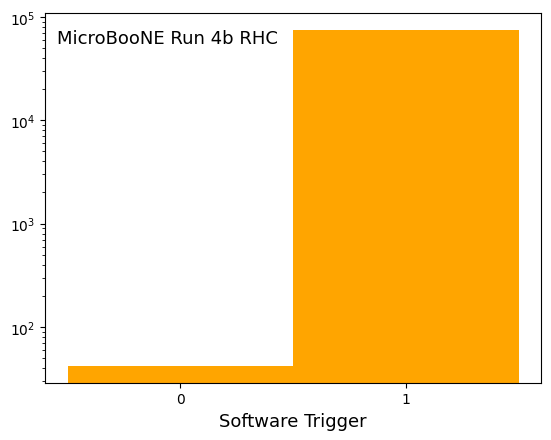

Signal passing SW trigger =  74774.03125
Signal failing SW trigger =  41.99422836303711


In [34]:
# Pass or fail software trigger plot for intrinsic nue
n = plt.hist(nue.query('is_signal==True').swtrig_pre, bins=[-0.5, 0.5, 1.5], color='orange', 
         weights=nue.query('is_signal==True')['totweight_intrinsic'])[0]

plt.xlabel("Software Trigger", fontsize=13)
plt.xticks([0,1])
plt.yscale("log")

plt.text(0.025, 0.92, "MicroBooNE Run 4b RHC",
        fontsize=13, transform=plt.gca().transAxes, horizontalalignment='left')

plt.savefig('sw_trigger_run4brhc.pdf', transparent=False, bbox_inches='tight')

plt.show()

print('Signal passing SW trigger = ', n[1])
print('Signal failing SW trigger = ', n[0])

# Linear selection

This is the original linear selection!

In [35]:
# # PRESELECTION

# PRE_QUERY = 'swtrig_pre==1 and nslice==1' # 
# PRE_QUERY += ' and ' + reco_in_fv_query 
# PRE_QUERY += ' and contained_fraction>0.9' 

# PRE_QUERY += ' and n_showers_contained == 1'
# PRE_QUERY += ' and n_tracks_contained>0'
# PRE_QUERY += ' and trk_energy>0.04' 


In [36]:
# # new optimized selection by Kaushal 

# SEL_QUERY = PRE_QUERY

# SEL_QUERY += ' and shr_score<0.125'
# SEL_QUERY += ' and shrmoliereavg<8'
# SEL_QUERY += ' and trkpid<0'

# SEL_QUERY += ' and shr_tkfit_dedx_Y<4'

# if not ISRUN3: 
#     SEL_QUERY += ' and tksh_distance<5'

# else: 
#     SEL_QUERY += ' and tksh_distance<4'

This is the Run 3 and Run 4b comparison selection I was using (to see what I expected out of Run 4b)

In [37]:
# RUN 4b AND RUN 3 COMPARISON SELECTION ("NUMU" IN UNCERTAINTY.IPYNB)

# PRE_QUERY = 'swtrig_pre == 1 and slice_orig_pass_id == 1' # 
# PRE_QUERY += ' and ' + reco_in_fv_query 
# PRE_QUERY += ' and contained_fraction > 0.9' 
# PRE_QUERY += ' and n_showers_contained == 1'
# PRE_QUERY += ' and n_tracks_contained > 0'

# PRE_QUERY += ' and trk_energy > 0.04' 
# PRE_QUERY += ' and shr_score < 0.3'
# PRE_QUERY += ' and trkpid < 0.35'
# PRE_QUERY += ' and pfng2hipfrac > 0.6'

This is the test BDT selection!

In [38]:
# ## Test BDT selection 
# PRE_QUERY = 'swtrig_pre == 1'
# PRE_QUERY += ' and slice_orig_pass_id == 1' 
# PRE_QUERY += ' and ' + reco_in_fv_query
# PRE_QUERY +=' and contained_fraction > 0.9'

# # signal definition - shower constraints
# PRE_QUERY += ' and n_pfng2_showers == 1'
# # signal definition - michel electron phase space constraint
# PRE_QUERY += ' and shr_energy_tot_cali > 0.07'

# # signal definition - track constraints
# PRE_QUERY += ' and n_pfng2_tracks > 0'
# PRE_QUERY += ' and trk_energy > 0.04'

# # # loose shower constraints
# # PRE_QUERY += ' and shr_score < 0.3'
# # PRE_QUERY += ' and shrmoliereavg < 15'

# # loose track constraints (including NuGraph variables)
# # PRE_QUERY += ' and trkpid < 0.35'
# # PRE_QUERY += ' and tksh_distance < 12'


This is the same as what is in top.py

In [39]:
# quality cuts
BDT_PRE_QUERY = 'swtrig_pre == 1'
BDT_PRE_QUERY += ' and slice_orig_pass_id == 1' 
BDT_PRE_QUERY += ' and ' + reco_in_fv_query
BDT_PRE_QUERY += ' and contained_fraction > 0.9'

# signal definition - shower constraints
BDT_PRE_QUERY += ' and n_showers_contained == 1'

# signal definition - michel electron phase space constraint
BDT_PRE_QUERY += ' and shr_energy_tot_cali > 0.07'

# signal definition - track constraints
BDT_PRE_QUERY += ' and n_tracks_contained > 0'
BDT_PRE_QUERY += ' and trk_energy > 0.04'

BDT_LOOSE_CUTS = BDT_PRE_QUERY

# loose shower constraints
BDT_LOOSE_CUTS += ' and shrmoliereavg < 15'

# loose track constraints (including NuGraph variables)
BDT_LOOSE_CUTS += ' and trkpid < 0.35'
BDT_LOOSE_CUTS += ' and tksh_distance < 12'

Linear selection - for BDT training comparison

In [40]:
SEL_QUERY = 'swtrig_pre == 1'
SEL_QUERY += ' and slice_orig_pass_id == 1'
SEL_QUERY += ' and ' + reco_in_fv_query
SEL_QUERY +=' and contained_fraction > 0.9'
SEL_QUERY += ' and n_showers_contained == 1'
SEL_QUERY += ' and shr_energy_tot_cali > 0.07'
SEL_QUERY += ' and n_tracks_contained > 0'
SEL_QUERY += ' and trk_energy > 0.04'
SEL_QUERY += ' and shrmoliereavg < 8'
SEL_QUERY += ' and trkpid < 0'
SEL_QUERY += ' and shr_tkfit_dedx_Y < 4'
if not ISRUN3: 
    SEL_QUERY += ' and tksh_distance < 5'
else: 
    SEL_QUERY += ' and tksh_distance < 4'

In [41]:
# Calculate cumulative efficiency, purity, and efficiency*purity after each cut

# total_signal_generated: all the true signal events generated (before cuts)
# signal_selected: Signal events that pass the selection cuts
# total_selected: ALL events that pass the selection cuts (signal + background) 

# Define individual cuts in order
cuts = [
    ('swtrig_pre == 1', 'Software Trigger'),
    ('slice_orig_pass_id == 1', 'Slice Pass ID'),
    (reco_in_fv_query, 'Reco in FV'),
    ('contained_fraction > 0.9', 'Contained Fraction > 0.9'),
    ## SIGNAL DEFINITION
    ('n_showers_contained == 1', 'N Showers Contained = 1'),
    ('shr_energy_tot_cali > 0.07', 'Shower Energy > 70 MeV'),
    ('n_tracks_contained > 0', 'N Tracks Contained > 0'),
    ('trk_energy > 0.04', 'Track Energy > 0.04'),
    ## BDT LOOSE CUTS - NOT VARIABLES BEING FED INTO THE BDT!
    ## Loose numu rejection
    ('trkpid < 0.35', 'Track PID Score < 0.35'),
    ## Loose neutral pion rejection,
    ('shrmoliereavg < 15', 'Average Shower Moliere Angle < 15 degrees'),
    ('tksh_distance < 12', 'Track-Shower Distance < 12 cm')
]

# Get total signal generated (before any cuts) (weighted to beam-on POT)
total_signal_generated = sum(generated_signal(ISRUN3, 'nu_e', [0,100], 0, 100)[0])

print("="*80)
print("CUMULATIVE SELECTION CUT ANALYSIS")
print("="*80)
print(f"Total Signal Generated: {total_signal_generated:.2f} events\n")

# Build cumulative query
cumulative_query = ""
for i, (cut, description) in enumerate(cuts):
    # Add current cut to cumulative query
    if i == 0:
        cumulative_query = cut
    else:
        cumulative_query += ' and ' + cut
    
    # Calculate signal selected (weighted to bean-on POT)
    signal_selected = np.nansum(datasets['infv'].query(cumulative_query + ' and is_signal==True')['totweight_data'])
    
    # Calculate total selected (signal + background from infv, outfv, and ext)
    total_selected = (np.nansum(datasets['infv'].query(cumulative_query)['totweight_data']) + 
                      np.nansum(datasets['outfv'].query(cumulative_query)['totweight_data']) + 
                      np.nansum(datasets['ext'].query(cumulative_query)['pot_scale']))
    
    # Calculate metrics
    efficiency = (signal_selected / total_signal_generated) * 100
    purity = (signal_selected / total_selected) * 100 if total_selected > 0 else 0
    eff_times_pur = (efficiency * purity) / 100
    
    # Print results
    print(f"Cut {i+1}: {description}")
    print(f"  Query: {cut}")
    print(f"  Signal Selected: {signal_selected:.2f}")
    print(f"  Total Selected: {total_selected:.2f}")
    print(f"  Efficiency: {efficiency:.2f}%")
    print(f"  Purity: {purity:.2f}%")
    print(f"  Efficiency × Purity: {eff_times_pur:.2f}%")
    print("-"*80)

print("\nFinal Selection Query:")
print(BDT_LOOSE_CUTS)

Adding pot_scale column using dirt & EXT tune....
CUMULATIVE SELECTION CUT ANALYSIS
Total Signal Generated: 743.50 events

Cut 1: Software Trigger
  Query: swtrig_pre == 1
  Signal Selected: 743.08
  Total Selected: 1350391.23
  Efficiency: 99.94%
  Purity: 0.06%
  Efficiency × Purity: 0.05%
--------------------------------------------------------------------------------
Cut 1: Software Trigger
  Query: swtrig_pre == 1
  Signal Selected: 743.08
  Total Selected: 1350391.23
  Efficiency: 99.94%
  Purity: 0.06%
  Efficiency × Purity: 0.05%
--------------------------------------------------------------------------------
Cut 2: Slice Pass ID
  Query: slice_orig_pass_id == 1
  Signal Selected: 617.45
  Total Selected: 173958.66
  Efficiency: 83.05%
  Purity: 0.35%
  Efficiency × Purity: 0.29%
--------------------------------------------------------------------------------
Cut 2: Slice Pass ID
  Query: slice_orig_pass_id == 1
  Signal Selected: 617.45
  Total Selected: 173958.66
  Efficiency

# Plotting Selection Variables

total selected = 532.8137216509701


/exp/uboone/app/users/abarnard/thesis_analysis/selection/backend_functions/selection_functions.py:335: RuntimeWarning: invalid value encountered in divide
  ext_percent_err = np.sqrt(ext_counts)/n[-1]
/exp/uboone/app/users/abarnard/thesis_analysis/selection/backend_functions/selection_functions.py:336: RuntimeWarning: invalid value encountered in divide
  mc_percent_err = mc_err/n[-1]


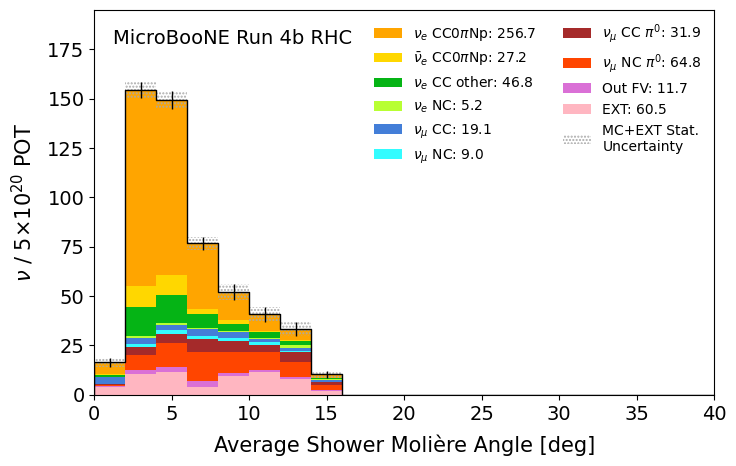

In [42]:
# NO EXT - FOR A MORE DIRECT COMPARISON

from backend_functions.selection_functions import plot_mc_no_ext
from selection_functions import plot_mc
import matplotlib.pyplot as plt

# Get the plot data and extract the total selected events
bins = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
xlow = bins[0]
xhigh = bins[-1]

x = plot_mc('shrmoliereavg', bins, xlow, xhigh, BDT_LOOSE_CUTS, 
            datasets, ISRUN3, x_label="Average Shower Molière Angle [deg]", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=False, xmax=xhigh, ymax=195)

In [43]:
# NO EXT - FOR A MORE DIRECT COMPARISON
# Get the plot data and extract the total selected events
bins = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]
xlow = bins[0]
xhigh = bins[-1]

x = plot_mc_no_ext('shr_tkfit_dedx_Y', bins, xlow, xhigh, PRE_QUERY, 
            datasets, ISRUN3, x_label=r"$\mathrm{d}\mathit{E}/\mathrm{d}\mathit{x}$ on the Collection Plane [MeV/cm]", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=False, xmax=xhigh, ymax=140)

NameError: name 'PRE_QUERY' is not defined

In [ ]:
# NO EXT - FOR A MORE DIRECT COMPARISON
# Get the plot data and extract the total selected events
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
xlow = bins[0]
xhigh = bins[-1]

x = plot_mc_no_ext('tksh_distance', bins, xlow, xhigh, PRE_QUERY, 
            datasets, ISRUN3, x_label="3D Distance Between Track & Shower [cm]", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=False, xmax=xhigh, ymax=150)

In [ ]:
# NO EXT - FOR A MORE DIRECT COMPARISON
# Get the plot data and extract the total selected events
bins = [-1.00, -0.90, -0.80, -0.70, -0.60, -0.50, -0.40, -0.30, -0.20, -0.10, 0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
xlow = bins[0]
xhigh = bins[-1]
x_ticks = [-1.00, -0.75, -0.50, -0.25, 0.00, 0.25, 0.50, 0.75, 1.00]

x = plot_mc('trkpid', bins, xlow, xhigh, BDT_PRE_QUERY, 
            datasets, ISRUN3, x_label="Track PID Score", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=xhigh, ymax=850, x_ticks=x_ticks)

In [ ]:
draw_root_like(nue['shr_score'], bins='auto', xlabel='shr_score', title='shr_score (nue)', logy=False, max_value=0.1)

# BDT Selection

In [ ]:
# load bdt model 
split = 1
bdt_model = xgb.Booster({'nthread': 4})
bdt_model.load_model(parameters(ISRUN3)['bdt_model'])
    
datasets_bdt = {}

for i in range(len(datasets)): 

    df = list(datasets.values())[i].copy()
    df = df.query(BDT_LOOSE_CUTS)

    # clean datasets 
    for column in training_parameters:
        df.loc[(df[column] < -1.0e37) | (df[column] > 1.0e37), column] = np.nan

    # create testing dmatrix 
    df_test = xgb.DMatrix(data=df[training_parameters])

    # apply the bdt selection
    preds = bdt_model.predict(df_test)

    # add columns for plotting 
    df['BDT_score'] = preds

    datasets_bdt[list(datasets.keys())[i]] = df
    

In [ ]:
bdt_score_cut = parameters(ISRUN3)['bdt_score_cut']
    
print("BDT SCORE THRESHOLD = "+str(bdt_score_cut))

selected_query = BDT_LOOSE_CUTS + ' and BDT_score>'+str(bdt_score_cut)
selected_signal_query = selected_query + ' and is_signal==True'


In [ ]:
datasets_bdt['outfv'].nu_e

In [ ]:
print("GENERATED SIGNAL (DATA NORMALIZED) = "+str(sum(top.generated_signal(ISRUN3, 'nu_e', [0,20], 0, 20)[0]))) # Is this weight the default?

In [ ]:
# BDT score output 

x = plot_mc('BDT_score', [round(x*0.1, 2) for x in range(11)], 0, 1, BDT_LOOSE_CUTS, 
            datasets_bdt, ISRUN3, x_label="BDT Score", # 'BDT Probability Score'
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=0.8, ymax=170)#, ymax=100)

In [ ]:
x = plot_mc('BDT_score', [round(x*0.025, 3) for x in range(0,41)], 0.075, 0.8, BDT_LOOSE_CUTS, 
            datasets_bdt, ISRUN3, x_label="BDT Score", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=0.8, ymax=55)#, ymax=100)

In [1]:
bins = [0.02, 0.42, 0.62, 0.82, 1.22, 7.00]
xlow = bins[0]
xhigh = 2.5 # Previously 3, wants to be changed to 2.5! 
    
x_label = "Electron Energy [GeV]"
x_ticks = [0.02, 0.42, 0.62, 0.82, 1.22]

# Create the BDT selection query with score > 0.55
bdt_query = BDT_LOOSE_CUTS + ' and BDT_score > 0.55'

x = plot_mc('shr_energy_cali', bins, xlow, xhigh, bdt_query, 
            datasets_bdt, ISRUN3, x_label=x_label, 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=xhigh, ymax=100, x_ticks=x_ticks)

NameError: name 'BDT_LOOSE_CUTS' is not defined

In [ ]:
bins = [0.05, 0.45, 0.65, 0.85, 1.05, 1.35, 1.85, 7.00]
xlow = bins[0]
xhigh = 3 # Previously 4, wants to be changed to 3! 
x_label = "Visible Energy [GeV]"
x_ticks = [0.05, 0.45, 0.65, 0.85, 1.05, 1.35, 1.85]

# Create the BDT selection query with score > 0.55
bdt_query = BDT_LOOSE_CUTS + ' and BDT_score > 0.55'

x = plot_mc('NeutrinoEnergy2_GeV', bins, xlow, xhigh, bdt_query, 
            datasets_bdt, ISRUN3, x_label=x_label, 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=False, xmax=xhigh, ymax=60, x_ticks=x_ticks)

### Performance 

#### SHAP Analysis

In [ ]:
# Simple SHAP setup
import shap
import xgboost as xgb

# Load training data using the function from selection_functions
training_data_file = 'BDT_training_data/training_data_run4brhc_scaled_noext.pkl'
X_train, y_train, X_test, y_test, feature_names, data_package = load_training_data_for_shap(training_data_file)

# Load model (use existing bdt_model from session)
model = bdt_model

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

print("✅ SHAP setup complete!")
print(f"Training samples: {len(X_test)}")
print(f"Features: {len(feature_names)}")
print("Ready for SHAP analysis!")

In [ ]:
import numpy as np
import pandas as pd

print("🧹 Cleaning X_test for SHAP analysis...")

# Step 1: Replace infinite values (±inf) with NaN
X_test_clean = X_test.replace([np.inf, -np.inf], np.nan)

# Step 2: Detect “float overflow” placeholder values (~3.4e38)
# (These often appear when float32 values overflow or are used to mark missing data)
float32_max = np.finfo(np.float32).max
mask_overflow = (X_test_clean.abs() >= float32_max * 0.9)  # near the limit
overflow_count = mask_overflow.sum().sum()
if overflow_count > 0:
    print(f"⚠️ Found {overflow_count} extreme float values near ±3.4e38. Replacing with NaN...")
    X_test_clean = X_test_clean.mask(mask_overflow, np.nan)

# Step 3: Handle NaNs — choose fill strategy
# Option A: fill with 0 (neutral baseline)
X_test_clean = X_test_clean.fillna(0)
# Option B (optional): fill with column means instead
# X_test_clean = X_test_clean.fillna(X_test_clean.mean())

# Step 4: Clip any remaining extreme magnitudes (optional safeguard)
X_test_clean = X_test_clean.clip(-1e10, 1e10)

# Step 5: Confirm everything is finite
if not np.isfinite(X_test_clean.to_numpy()).all():
    print("⚠️ Non-finite values remain! Double-check preprocessing.")
else:
    print("✅ Data cleaned: all values finite and within safe range.")

# (Optional) preview a few columns with formerly huge values
cols_with_large = (mask_overflow.sum() > 0)
if cols_with_large.any():
    print("Columns affected by cleaning:")
    print(X_test.columns[cols_with_large].tolist())
# Step 6: Use the cleaned dataset going forward
X_test = X_test_clean

Making the SHAP beeswarm plot using shap.plots.beeswarm. Here, I'm using the test dataset. 

In [ ]:
# SHAP Beeswarm Plot with Direction Labels
import shap
import matplotlib.pyplot as plt
import numpy as np

try:
    # Check if we have everything needed from the previous cell
    if 'explainer' in locals() and explainer is not None and 'X_test' in locals() and X_test is not None:
        print("Generating SHAP beeswarm plot...")
        
        # For computational efficiency, use a sample of training data
        sample_size = min(277005, len(X_test))
        X_sample = X_test.sample(n=sample_size, random_state=42)
        
        print(f"Computing SHAP values for {sample_size} samples...")
        shap_values = explainer.shap_values(X_sample)
        
        # Create the beeswarm plot
        plt.figure(figsize=(12, 8))
        shap.plots.beeswarm(
            shap.Explanation(
                values=shap_values if not isinstance(shap_values, list) else shap_values[0],
                data=X_sample.values,
                feature_names=feature_names
            ),
            max_display=15,
            show=False
        )
        
        # --- Modify tick label font ---
        ax = plt.gca()
        for label in ax.get_yticklabels():
            label.set_fontfamily('monospace')
            label.set_fontsize(11)
        
        # --- Add custom axis and colorbar labels ---
        plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
        fig = plt.gcf()
        axes = fig.get_axes()
        if len(axes) > 1:
            cbar = axes[-1]
            cbar.set_ylabel("Feature Value", fontsize=12)
        
        # --- Title ---
        plt.title('SHAP Beeswarm Plot - Run 4b RHC BDT (Scaled, No Ext)', fontsize=12)
        
        # --- Add custom "direction" text labels ---
        # Get current axis limits so we position the text correctly
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        
        # Add text slightly below the x-axis limits
        y_pos = y_min + 0.5  # adjust if text overlaps or is too far
        
        ax.text(x_min, y_pos, "← Away from Signal", fontsize=11, ha='left', va='top', color='dimgray')
        ax.text(x_max, y_pos, "Towards Signal →", fontsize=11, ha='right', va='top', color='dimgray')
        
        # --- Layout and show ---
        plt.tight_layout()
        plt.savefig('shap_beeswarm_run4brhc_scaled_noext_labels.pdf', bbox_inches='tight')
        plt.show()
        
        print("✅ SHAP beeswarm plot generated successfully!")
        print("This plot shows:")
        print("- Features ordered by importance (top to bottom)")
        print("- Each dot represents one sample")
        print("- X-axis shows SHAP value (impact on model output)")
        print("- Color indicates feature value (red=high, blue=low)")
        print("- Direction labels indicate movement away/towards the signal")
        
    else:
        print("❌ Missing required data for beeswarm plot")
        
except Exception as e:
    print(f"Error generating beeswarm plot: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type='violin')

In [ ]:
int_labels = {
    '0': 'CCQE', 
    '1': 'CC Res', 
    '2': 'CC DIS', 
    '3': 'CC Coh', 
    '10': 'CC MEC' 
}

fig = plt.figure(figsize=(8, 5))

xvar = 'nu_e'

ccqe = datasets_bdt['infv'].query(selected_signal_query+' and interaction==0')
ccres = datasets_bdt['infv'].query(selected_signal_query+' and interaction==1')
ccdis = datasets_bdt['infv'].query(selected_signal_query+' and interaction==2')
cccoh = datasets_bdt['infv'].query(selected_signal_query+' and interaction==3')
ccmec = datasets_bdt['infv'].query(selected_signal_query+' and interaction==10')

int_weights = [ccqe['totweight_data'], 
                 ccres['totweight_data'], 
                 ccdis['totweight_data'], 
                 cccoh['totweight_data'], 
                 ccmec['totweight_data']]

int_counts = []
for l in int_weights: 
    int_counts.append( np.nansum(l) )
    
tot_count = sum(int_counts)
int_counts = [str(round((x/tot_count)*100, 1)) for x in int_counts]

# signal broken down by interactions after the selection 
n, b, p = plt.hist([ccqe[xvar], ccres[xvar], ccdis[xvar], cccoh[xvar], ccmec[xvar]],
          [x*0.25 for x in range(25)], 
          weights=int_weights,
          label=[int_labels['0']+' ('+int_counts[0]+'%)', 
                 int_labels['1']+' ('+int_counts[1]+'%)', 
                 int_labels['2']+' ('+int_counts[2]+'%)', 
                 int_labels['3']+' ('+int_counts[3]+'%)', 
                 int_labels['10']+' ('+int_counts[4]+'%)'],
          color=[ 'blueviolet','cornflowerblue','navy',  'orangered', 'deeppink'], # Change colours here!
          stacked=True)

bincenters = 0.5*(b[1:]+b[:-1])

y_err = mc_error(xvar, b, b[0], b[-1], [datasets_bdt['infv'].query(selected_signal_query)])
#y_err = [x*y for x, y in zip(n[-1], signal_percent_err)]

plt.hist(bincenters, b, color='black', linewidth=0.75, weights=n[-1], histtype='step')
plt.errorbar(bincenters, n[-1], yerr=y_err,
             color='black', linewidth=.75, fmt='none')#, alpha=.7)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel("True Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('$\\nu$ / $2\\times10^{20}$ POT', fontsize=15)
#plt.title('FHC RUN 1 Selected Event Rate', fontsize=16)

plt.legend(frameon=False, fontsize=14)

plt.xlim(0, 6)

#plt.savefig("/uboone/app/users/abarnard/katrina_analysis/code/uBNuMI_CC1eNp/FHCSelectedInteractions.pdf", transparent=True, bbox_inches='tight') 

#plt.savefig(parameters(ISRUN3)['plots_path']+"FHCSelectedInteractions.pdf", transparent=True, bbox_inches='tight') 

plt.show()

In [ ]:
q = BDT_LOOSE_CUTS+' and BDT_score>'+str(bdt_score_cut)
q

In [ ]:
useBDT = True

if useBDT: 
    datasets_dict = datasets_bdt
else: 
    datasets_dict = datasets

In [ ]:

tot_sig_sel = np.nansum(datasets_dict['infv'].query(q+' and is_signal==True').totweight_data)
tot_sel = np.nansum(datasets_dict['infv'].query(q).totweight_data) + np.nansum(datasets_dict['outfv'].query(q).totweight_data) + np.nansum(datasets_dict['ext'].query(q).pot_scale)
tot_sig = sum(generated_signal(ISRUN3, 'nu_e', [0,100], 0, 100)[0])

print("Efficiency = ", tot_sig_sel/tot_sig)
print("Purity = ", tot_sig_sel/tot_sel)


In [ ]:
datasets_dict['infv'].query(q+' and is_signal==True')["shr_energy_cali"].min()

In [ ]:
datasets_dict['data'].query(q)["shr_energy_cali"].min()

## BDT Training

In [ ]:
TRAIN = True
save_bdt = True

In [ ]:
# ========================================
# TOGGLE: Set to False to exclude EXT from BDT training
# ========================================
USE_EXT_IN_BDT = False

# When False: BDT trains on MC signal vs background only (no beam-off EXT data)
# When True: BDT trains with EXT included as additional background (original behavior)

In [ ]:
# Conditionally build datasets dictionary based on USE_EXT_IN_BDT flag
# Override previous 'datasets' definition for BDT training
if USE_EXT_IN_BDT:
    datasets = {
        "infv": infv, 
        "outfv": outfv,
        "ext": ext 
    }
    print("Datasets created WITH EXT for BDT training")
else:
    datasets = {
        "infv": infv, 
        "outfv": outfv
    }
    print("Datasets created WITHOUT EXT for BDT training")

In [ ]:
# Verify the datasets dictionary structure
print("Available datasets:", list(datasets.keys()))
print("USE_EXT_IN_BDT is set to:", USE_EXT_IN_BDT)
print("\nDataset sizes:")
for key, df in datasets.items():
    print(f"  {key}: {len(df):,} events")

In [ ]:

# TRAIN ON A SUBSET OF THE DISTRIBUTION
train_query = BDT_LOOSE_CUTS + ' and -0.9<tksh_angle<0.9' #and shr_energy_tot_cali>0.07'
test_query = BDT_LOOSE_CUTS


In [ ]:
# subset distributions 

x = plot_mc_no_ext('tksh_angle', [-1, -.9, -.8, -.7, -.6, -.5, -.4, -.3, -.2, -.1] + list(round(x*0.1,2) for x in range(11)), 
        -1, 1, test_query, datasets, ISRUN3, norm='data')
        #save=False, save_label='RHCRUN3_loosecuts_mconly', log=False, x_label='$cos(\\theta_{ep})$',
        #text='FHC RUN 1', xtext=0.75, ytext=70)

x = plot_mc_no_ext('shr_energy_tot_cali', list(x*0.01 for x in range(21)), 
        0, 0.2, test_query, datasets, ISRUN3, norm='data', ymax=65)
        #save=False, save_label='RHCRUN3_loosecuts_mconly', log=False, x_label='Total Calibrated Shower Energy [GeV]', 
        #text='FHC RUN 1', xtext=0.19, ytext=35)


In [ ]:
# df_pre = addRelevantColumns(datasets) 
df_pre = addRelevantColumns_flexible(datasets, USE_EXT_IN_BDT=USE_EXT_IN_BDT)

In [ ]:
total_signal_generated_intrinsic = sum(top.generated_signal(ISRUN3, 'nu_e', [0,100], 0, 100, weight='totweight_intrinsic')[0])
print(total_signal_generated_intrinsic)

In [ ]:
total_signal_generated = sum(generated_signal(ISRUN3, 'nu_e', [0,100], 0, 100)[0])
print(total_signal_generated)

#### Pre BDT performance as a function of test sample size 

In [ ]:
# efficiency of total sample 
e_total = sum(df_pre.query(test_query+ ' and is_signal==True')['weight']) / total_signal_generated 

# efficiency error - binomial (use the intrinsic event count)
e_total_err = np.sqrt(e_total * (1-e_total) / total_signal_generated_intrinsic) * 100 

# purity of total sample 
p_total = sum(df_pre.query(test_query+ ' and is_signal==True')['weight']) / sum(df_pre.query(test_query)['weight'])

# purity error - poissonian 
p_total_err = (p_total * np.sqrt( sum(df_pre.query(test_query+' and is_signal==True').weight**2)/(sum(df_pre.query(test_query+' and is_signal==True').weight)**2) + sum(df_pre.query(test_query).weight**2)/(sum(df_pre.query(test_query).weight)**2) )) * 100

e_total = e_total*100
p_total = p_total*100


# store efficiency & purity values
e = []
e_err = []

p = []
p_err = []

xpoints = [round(i*0.05, 2) for i in range(20)]

for test_size in xpoints[1:]: 

    df_pre_train, df_pre_test = train_test_split(df_pre, test_size=test_size, 
                                             random_state=17, stratify=df_pre['is_signal'])
    
    total_signal_selected = sum(df_pre_test.query(test_query+ ' and is_signal==True')['weight'])
    total_selected = sum(df_pre_test.query(test_query)['weight'])
    
    eff = total_signal_selected / (total_signal_generated*test_size) 
    pur = total_signal_selected / total_selected
    
    e.append(eff*100)
    p.append(pur*100)
    
    e_err.append( np.sqrt( (eff*(1-eff)) / (total_signal_generated_intrinsic*test_size) ) * 100) # use the intrinsic event count
    p_err.append( (pur * np.sqrt( sum(df_pre_test.query(test_query+' and is_signal==True').weight**2)/sum(df_pre_test.query(test_query+' and is_signal==True').weight)**2 + sum(df_pre_test.query(test_query).weight**2)/sum(df_pre_test.query(test_query).weight)**2) )*100 ) 
                 

In [ ]:

plt.figure(figsize=(7.5, 5))

plt.errorbar(xpoints[1:], p, yerr=p_err, label="Purity (Test Sample)", color='firebrick', marker='.')
plt.axhline(y=p_total, label="Purity (Full)", color='firebrick', linewidth=1, linestyle="--")

plt.fill_between(xpoints, p_total-p_total_err, p_total+p_total_err, color='firebrick', alpha=0.1)


plt.ylim(40, 70)
plt.xlim(xpoints[0], xpoints[-1])
plt.grid(linestyle=':')
plt.legend(fontsize=13, ncol=2)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel('Test Sample Size (Relative to Full Sample)', fontsize=14)
plt.ylabel('Performance (%)', fontsize=14)

if ISRUN3: 
    plt.title('Run 4b RHC Pre-BDT Purity', fontsize=15)
#    plt.savefig(parameters(ISRUN3)['plots_path']+"RHCStratPerf_Purity.pdf", transparent=True, bbox_inches='tight') 
else: 
    plt.title('FHC Run 1 Pre-BDT Purity', fontsize=15)
#    plt.savefig(parameters(ISRUN3)['plots_path']+"FHCStratPerf_Purity.pdf", transparent=True, bbox_inches='tight') 


plt.show()



In [ ]:

plt.figure(figsize=(7.5, 5))

plt.errorbar(xpoints[1:], e, yerr=e_err, label="Efficiency (Test Sample)", color='seagreen', marker='.')
plt.axhline(y=e_total, label="Efficiency (Full)", color='seagreen', linewidth=1, linestyle="--")

plt.fill_between(xpoints, e_total-e_total_err, e_total+e_total_err, color='seagreen', alpha=0.1)


plt.ylim(30, 40)
plt.xlim(xpoints[0], xpoints[-1])
plt.grid(linestyle=':')
plt.legend(fontsize=13, ncol=2)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel('Test Sample Size (Relative to Full Sample)', fontsize=14)
plt.ylabel('Performance (%)', fontsize=14)

if ISRUN3: 
    plt.title('Run 4b RHC Pre-BDT Efficiency', fontsize=15)
    #plt.savefig(parameters(ISRUN3)['plots_path']+"RHCStratPerf_Efficiency.pdf", transparent=True, bbox_inches='tight') 
else: 
    plt.title('FHC Run 1 Pre-BDT Efficiency', fontsize=15)
    #plt.savefig(parameters(ISRUN3)['plots_path']+"FHCStratPerf_Efficiency.pdf", transparent=True, bbox_inches='tight') 

plt.show()

In [ ]:
# Calculate optimal test sample size based on convergence with full sample

# Convert to numpy arrays for easier calculation
e_array = np.array(e)
p_array = np.array(p)
e_err_array = np.array(e_err)
p_err_array = np.array(p_err)
xpoints_array = np.array(xpoints[1:])

# Find where efficiency converges (within uncertainty band of full sample)
# Check if test sample value is within the full sample uncertainty band
eff_converged = np.abs(e_array - e_total) <= e_total_err

# Find where purity converges
pur_converged = np.abs(p_array - p_total) <= p_total_err

# Find the first point where each metric converges
eff_convergence_idx = np.argmax(eff_converged) if np.any(eff_converged) else None
pur_convergence_idx = np.argmax(pur_converged) if np.any(pur_converged) else None

print("=" * 80)
print("CONVERGENCE ANALYSIS")
print("=" * 80)
print(f"\nFull Sample Efficiency: {e_total:.2f} ± {e_total_err:.2f}%")
print(f"Full Sample Purity: {p_total:.2f} ± {p_total_err:.2f}%")

if eff_convergence_idx is not None:
    eff_convergence_size = xpoints_array[eff_convergence_idx]
    print(f"\nEfficiency first converges at test size: {eff_convergence_size:.2f}")
    print(f"  Value at convergence: {e_array[eff_convergence_idx]:.2f} ± {e_err_array[eff_convergence_idx]:.2f}%")
    print(f"  Deviation from full: {abs(e_array[eff_convergence_idx] - e_total):.2f}%")
else:
    print("\nEfficiency does not converge within the tested range")

if pur_convergence_idx is not None:
    pur_convergence_size = xpoints_array[pur_convergence_idx]
    print(f"\nPurity first converges at test size: {pur_convergence_size:.2f}")
    print(f"  Value at convergence: {p_array[pur_convergence_idx]:.2f} ± {p_err_array[pur_convergence_idx]:.2f}%")
    print(f"  Deviation from full: {abs(p_array[pur_convergence_idx] - p_total):.2f}%")
else:
    print("\nPurity does not converge within the tested range")

# Find optimal test size (where BOTH metrics have converged)
both_converged = eff_converged & pur_converged
if np.any(both_converged):
    optimal_idx = np.argmax(both_converged)
    optimal_test_size = xpoints_array[optimal_idx]
    print(f"\n{'=' * 80}")
    print(f"OPTIMAL TEST SIZE (where both metrics converge): {optimal_test_size:.2f}")
    print(f"{'=' * 80}")
    print(f"  Efficiency: {e_array[optimal_idx]:.2f} ± {e_err_array[optimal_idx]:.2f}% (Full: {e_total:.2f}%)")
    print(f"  Purity: {p_array[optimal_idx]:.2f} ± {p_err_array[optimal_idx]:.2f}% (Full: {p_total:.2f}%)")
    print(f"  Efficiency deviation: {abs(e_array[optimal_idx] - e_total):.2f}%")
    print(f"  Purity deviation: {abs(p_array[optimal_idx] - p_total):.2f}%")
else:
    # If we want a more conservative approach, find where both metrics 
    # are within 2x their uncertainty
    print(f"\n{'=' * 80}")
    print("Neither metric converges within 1σ, checking alternative criteria...")
    print(f"{'=' * 80}")
    
    # Alternative: take the larger of the two convergence points
    if eff_convergence_idx is not None and pur_convergence_idx is not None:
        optimal_test_size = max(eff_convergence_size, pur_convergence_size)
        print(f"\nRecommended test size (max of individual convergence): {optimal_test_size:.2f}")
    elif eff_convergence_idx is not None:
        optimal_test_size = eff_convergence_size
        print(f"\nRecommended test size (efficiency only): {optimal_test_size:.2f}")
    elif pur_convergence_idx is not None:
        optimal_test_size = pur_convergence_size
        print(f"\nRecommended test size (purity only): {optimal_test_size:.2f}")
    else:
        # Use the point with minimum combined relative deviation
        rel_eff_dev = np.abs(e_array - e_total) / e_total_err
        rel_pur_dev = np.abs(p_array - p_total) / p_total_err
        combined_dev = np.sqrt(rel_eff_dev**2 + rel_pur_dev**2)
        optimal_idx = np.argmin(combined_dev)
        optimal_test_size = xpoints_array[optimal_idx]
        print(f"\nRecommended test size (minimum combined deviation): {optimal_test_size:.2f}")
        print(f"  Efficiency deviation: {rel_eff_dev[optimal_idx]:.2f}σ")
        print(f"  Purity deviation: {rel_pur_dev[optimal_idx]:.2f}σ")
        print(f"  Combined deviation: {combined_dev[optimal_idx]:.2f}σ")

print(f"\n{'=' * 80}\n")

In [ ]:
# Visualize convergence with shaded regions

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Efficiency plot
ax1.errorbar(xpoints_array, e_array, yerr=e_err_array, label="Efficiency (Test Sample)", 
             color='seagreen', marker='o', markersize=5, linewidth=1.5)
ax1.axhline(y=e_total, label="Efficiency (Full Sample)", color='seagreen', linewidth=2, linestyle="--")
ax1.fill_between(xpoints, e_total-e_total_err, e_total+e_total_err, 
                  color='seagreen', alpha=0.2, label='Full Sample ±1σ')

# Mark convergence region for efficiency
if eff_convergence_idx is not None:
    ax1.axvline(x=eff_convergence_size, color='seagreen', linestyle=':', 
                alpha=0.5, linewidth=2, label=f'Convergence @ {eff_convergence_size:.2f}')
    ax1.axvspan(eff_convergence_size, xpoints[-1], alpha=0.1, color='seagreen')

ax1.set_ylabel('Efficiency (%)', fontsize=14)
ax1.grid(linestyle=':', alpha=0.5)
ax1.legend(fontsize=11, loc='lower right')
ax1.set_ylim(30, 40)
ax1.tick_params(axis='both', labelsize=13)


# Purity plot
ax2.errorbar(xpoints_array, p_array, yerr=p_err_array, label="Purity (Test Sample)", 
             color='firebrick', marker='o', markersize=5, linewidth=1.5)
ax2.axhline(y=p_total, label="Purity (Full Sample)", color='firebrick', linewidth=2, linestyle="--")
ax2.fill_between(xpoints, p_total-p_total_err, p_total+p_total_err, 
                  color='firebrick', alpha=0.2, label='Full Sample ±1σ')

# Mark convergence region for purity
if pur_convergence_idx is not None:
    ax2.axvline(x=pur_convergence_size, color='firebrick', linestyle=':', 
                alpha=0.5, linewidth=2, label=f'Convergence @ {pur_convergence_size:.2f}')
    ax2.axvspan(pur_convergence_size, xpoints[-1], alpha=0.1, color='firebrick')

ax2.set_xlabel('Test Sample Size (Relative to Full Sample)', fontsize=14)
ax2.set_ylabel('Purity (%)', fontsize=14)
ax2.grid(linestyle=':', alpha=0.5)
ax2.legend(fontsize=10, loc='lower right')
ax2.set_ylim(40, 70)
ax2.set_xlim(xpoints[0], xpoints[-1])
ax2.tick_params(axis='both', labelsize=13)

# Add optimal test size marker if both converge
if np.any(both_converged):
    for ax in [ax1, ax2]:
        ax.axvline(x=optimal_test_size, color='black', linestyle='-', 
                   alpha=0.7, linewidth=2.5, label=f'Optimal @ {optimal_test_size:.2f}')
        # Update legend to include optimal line
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=10, loc='lower right')

if ISRUN3:
    fig.suptitle('Run 4b RHC Pre-BDT Performance Convergence', fontsize=15, y=0.97)
else:
    fig.suptitle('FHC Run 1 Pre-BDT Performance Convergence', fontsize=15, y=0.995)

plt.tight_layout()

# plt.savefig("RHCStratPerf_Convergence_Scaled.pdf", transparent=True, bbox_inches='tight')

plt.show()

#### AUC & AUCPR Metrics

In [ ]:
final_test_size = 0.35

In [ ]:
import importlib
import backend_functions.selection_functions as selection_functions
importlib.reload(selection_functions)

In [ ]:
# Check the boosting rounds 

# Split arrays or matrices into random train and test subsets
df_pre_train, df_pre_test = selection_functions.train_test_split(df_pre, test_size=final_test_size, 
                                             random_state=17, stratify=df_pre['is_signal'])

selection_functions.bdt_metrics(df_pre_train, df_pre_test, train_query, test_query, 
            training_parameters, ISRUN3, save=True, verbose=False)

#### Create new BDT model 

In [ ]:
# pre-determined boosting round numbers
# Make sure to change this depending on performance above!

if not ISRUN3: # FHC
    lc_rounds = 200
    
else: # RHC
    lc_rounds = 500

#test train split 
split = final_test_size
print('split', split)


In [ ]:
import importlib
import backend_functions.selection_functions as selection_functions
importlib.reload(selection_functions)

In [ ]:
if TRAIN: 
    
    # BDT training - backend function cleans the dataset first 
    bdt_lc = selection_functions.main_BDT(datasets, train_query, test_query, lc_rounds, training_parameters, ISRUN3, test_size=split, USE_EXT_IN_BDT=USE_EXT_IN_BDT)

    results_df = bdt_lc['bdt_results_df']
    bdt_model = bdt_lc['bdt_model']
    train_df = bdt_lc['df_pre_train']
    test_df = bdt_lc['df_pre_test']
    
    # Split events into different categories based on is_mc flag and query
    # Reconstruct datasets_bdt from results_df
    datasets_bdt = {}
    
    # Split MC events into infv and outfv
    mc_results = results_df[results_df['is_mc'] == True].copy()
    datasets_bdt['infv'] = mc_results.query(in_fv_query) if 'in_fv_query' in dir() else mc_results[mc_results['is_signal'].notna()]
    datasets_bdt['outfv'] = mc_results.query(out_fv_query) if 'out_fv_query' in dir() else mc_results[mc_results['is_signal'] == False]
    
    # Add EXT if it was included in training
    if USE_EXT_IN_BDT and (results_df['is_mc'] == False).any():
        datasets_bdt['ext'] = results_df[results_df['is_mc'] == False].copy()

# note: all of the plots following be made with half the POT this way (test/train split)

In [ ]:
if save_bdt:
    import os
    os.makedirs('BDT_models', exist_ok=True)
    bdt_model.save_model('BDT_models/test_run4brhc_scaled_noext_noshrscore.model') 
    # Path to change which BDT you use is in the top.py script!
    print('saving BDT...')

### 💾 Accessing Training Data for Pre-trained BDT Models

Since BDT models don't store original training data, here are three approaches to access it later:

In [ ]:
# Save training data for later use (run this during/after BDT training)
if TRAIN and save_bdt:
    import os
    import pickle
    
    # Create directory for storing training data
    os.makedirs('BDT_training_data', exist_ok=True)
    
    # Save training data with metadata
    training_data_package = {
        'train_df': train_df,
        'test_df': test_df,
        'training_parameters': training_parameters,
        'train_query': train_query,
        'test_query': test_query,
        'split_ratio': split,
        'total_signal_generated': total_signal_generated,
        'total_signal_generated_intrinsic': total_signal_generated_intrinsic,
        'timestamp': pd.Timestamp.now().isoformat(),
        'model_path': 'BDT_models/test_run4brhc_scaled_noext_noshrscore.model'
    }
    
    # Save as pickle file
    with open('BDT_training_data/training_data_run4brhc_scaled_noext_noshrscore.pkl', 'wb') as f:
        pickle.dump(training_data_package, f)
    
    print("✅ Training data saved to 'BDT_training_data/training_data_run4brhc_scaled_noext_noshrscore.pkl'")
    print(f"   - Training events: {len(train_df):,}")
    print(f"   - Test events: {len(test_df):,}")
    print(f"   - Features: {len(training_parameters)}")
    print(f"   - Split ratio: {split}")
    
    # Also save just the essential training features as CSV for easy access
    train_features = train_df[training_parameters + ['is_signal', 'weight']].copy()
    train_features.to_csv('BDT_training_data/training_features_run4brhc_scaled_noext_noshrscore.csv', index=False)
    print("   - Training features also saved as CSV")
else:
    print("Skipping training data save (TRAIN=False or save_bdt=False)")

In [ ]:
import importlib
import backend_functions.selection_functions as selection_functions
importlib.reload(selection_functions)

In [ ]:
if TRAIN: 

    # performance of the linear selection for comparison
    gen_split = total_signal_generated*split
    eff_box = np.nansum(test_df.query(SEL_QUERY+' and is_signal==1').weight)/gen_split * 100

    tot_sel = np.nansum(test_df.query(SEL_QUERY)['weight']) 
    pur_box = np.nansum(test_df.query(SEL_QUERY+' and is_signal==1').weight) / tot_sel * 100

    results_box = [pur_box, eff_box]

    #  stat errors on the linear performance 
    e = eff_box/100

    eff_err = math.sqrt( (e*(1-e)) / total_signal_generated_intrinsic*split ) * 100
    pur_err = pur_box * np.sqrt( sum(test_df.query(SEL_QUERY+' and is_signal==1').weight**2)/sum(test_df.query(SEL_QUERY+' and is_signal==1').weight)**2 + sum(test_df.query(SEL_QUERY).weight**2)/sum(test_df.query(SEL_QUERY).weight)**2 )

    results_box_err = [pur_err, eff_err]

    # x values
    x = np.arange(0, 0.8, 0.025)

    # returns purity, purErr, eff, effErr
    perf_dict = selection_functions.bdt_pe(results_df, x, 
                  total_signal_generated, total_signal_generated_intrinsic, split)
    pur, pur_err, eff, eff_err = perf_dict['purity'], perf_dict['purErr'], perf_dict['eff'], perf_dict['effErr']
    
    selection_functions.bdt_box_plot([pur, pur_err, eff, eff_err], x, ISRUN3, save=False, results_box=results_box, results_box_err=results_box_err)

In [ ]:
bdt_svb_plot(results_df)

In [ ]:
## apply bdt model to the entire dataset

split = 1

datasets_bdt_full = {}

for i in range(len(datasets)): 

    df = list(datasets.values())[i].copy()
    df = df.query(BDT_LOOSE_CUTS)

    # clean datasets 
    for column in training_parameters:
        df.loc[(df[column] < -1.0e37) | (df[column] > 1.0e37), column] = np.nan

    # create testing dmatrix 
    df_test = xgb.DMatrix(data=df[training_parameters])

    # apply the bdt selection
    preds = bdt_model.predict(df_test)

    # add columns for plotting 
    df['BDT_score'] = preds

    datasets_bdt_full[list(datasets.keys())[i]] = df
  

In [ ]:
datasets_bdt_full.keys()

datasets_bdt_full['infv']['weight'] = list(datasets_bdt_full['infv'].totweight_data)
datasets_bdt_full['outfv']['weight'] = list(datasets_bdt_full['outfv'].totweight_data)

if USE_EXT_IN_BDT:
    datasets_bdt_full['ext']['weight'] = list(datasets_bdt_full['ext'].pot_scale)

In [ ]:
if USE_EXT_IN_BDT:
    datasets_bdt_full['tot_sim'] = pd.concat([datasets_bdt_full['infv'], datasets_bdt_full['outfv'], datasets_bdt_full['ext']])

else:
    datasets_bdt_full['tot_sim'] = pd.concat([datasets_bdt_full['infv'], datasets_bdt_full['outfv']])

#### Cross validation 

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold

In [ ]:

splits = 2
repeats = 20
cv = RepeatedStratifiedKFold(n_splits=splits, n_repeats=repeats, random_state=36851234)

if ISRUN3: 
    bdt_score_arr = np.arange(0, 0.75, 0.025)
    
else: 
    bdt_score_arr = np.arange(0, 0.8, 0.025)



In [ ]:
# Use the flexible function for cross-validation
df_crossval = selection_functions.addRelevantColumns_flexible(datasets, USE_EXT_IN_BDT=USE_EXT_IN_BDT)

scale_weight = len(df_crossval.query(train_query + ' and is_signal == False')) / len(df_crossval.query(train_query + ' and is_signal == True'))
print("scale pos weight (ratio of negative to positive) = "+str(scale_weight))

In [ ]:
len(df_crossval.query(train_query + ' and is_signal == False'))

In [ ]:
#model params
params = {
        'objective': 'binary:logistic',
        'booster': 'gbtree',
        'eta': 0.02,
        'tree_method': 'exact',
        'max_depth': 3,
        'subsample': 0.8,
        'colsample_bytree': 1,
        'silent': 1,
        'min_child_weight': 1,
        'seed': 2002,
        'gamma': 1,
        'max_delta_step': 0,
        'scale_pos_weight': scale_weight,
        'eval_metric': ['error', 'auc', 'aucpr']
}

In [ ]:
final_purity = []
final_efficiency=[]

fp_err = []
fe_err = []

box_pur = []
box_eff = []

boxp_err = []
boxe_err = []

print('Note: must use 50/50 split for the cv.split function to work!')

for train_index, test_index in cv.split(df_crossval, df_crossval['is_signal']):
    
    train, test = df_crossval.iloc[train_index], df_crossval.iloc[test_index]    
    
    bdt_cv_lc = selection_functions.bdt_raw_results(train, test, train_query, test_query, training_parameters, params, lc_rounds)
    
    # saves purity, efficiency and respective errors on current test sample for loose cuts BDT
    perf = selection_functions.bdt_pe(bdt_cv_lc[0], bdt_score_arr, total_signal_generated, total_signal_generated_intrinsic, 0.5)
    pur, pur_err, eff, eff_err = perf['purity'], perf['purErr'], perf['eff'], perf['effErr']
    
    final_purity.append(pur)
    final_efficiency.append(eff)
    
    fp_err.append(pur_err)
    fe_err.append(eff_err)

    # LINEAR SELECTION PERFORMANCE 
    
    sig_sel = sum(test.query(SEL_QUERY+' and is_signal==1').weight)
    tot_sel = sum(test.query(SEL_QUERY).weight)
    
    tot_sig = total_signal_generated*0.5
    tot_sig_intrinsic = total_signal_generated_intrinsic*0.5
    
    p = sig_sel / tot_sel
    e = sig_sel / tot_sig
    
    box_pur.append(p * 100)
    box_eff.append(e * 100)
        
    boxp_err.append( p * np.sqrt( sum(test.query(SEL_QUERY+' and is_signal==True').weight**2)/sum(test.query(SEL_QUERY+' and is_signal==True').weight)**2 + sum(test.query(SEL_QUERY).weight**2)/sum(test.query(SEL_QUERY).weight)**2 ) * 100)
    boxe_err.append(math.sqrt( (e * (1-e)) / tot_sig_intrinsic) * 100)

In [ ]:
# averages results column-wise, which is equivalent to averaging results over the same BDT_score cut

results_bdt = [np.mean(final_purity, axis=0), np.mean(fp_err, axis=0), 
               np.mean(final_efficiency, axis=0), np.mean(fe_err, axis=0)]

# linear box cut selection is a normal average over each distinct test sample
results_box = [np.mean(box_pur), np.mean(box_eff)]
results_box_err = [np.mean(boxp_err), np.mean(boxe_err)]

In [ ]:
for i in range(len(bdt_score_arr)): 
    if bdt_score_arr[i]>=0.45: 
        print("BDT score > "+str(round(bdt_score_arr[i], 3)))
        print("efficiency = "+str(round(results_bdt[2][i], 1)))
        print("purity = "+str(round(results_bdt[0][i], 1)))

In [ ]:
if ISRUN3: 
    title = "Run 4b RHC Cross Validation"
    save_label = "RUN4BRHC_crossvalidation_noshrscore"
else: 
    title = "FHC Run 1 Cross Validation"
    save_label = "FHCRUN1_crossvalidation"

In [ ]:
import importlib
import backend_functions.selection_functions as selection_functions
importlib.reload(selection_functions)

In [ ]:
print("Available variables:")
print("selection_variables:", selection_variables)
print("training_parameters:", training_parameters)

In [ ]:
bdt_box_plot(results_bdt, bdt_score_arr, ISRUN3, results_box=results_box, results_box_err=results_box_err, 
           save=False, save_label=save_label, title=title) 

# MC event selection (for making event displays)

## Extract selected events from intrinsic file

In [ ]:
# Filter signal events from datasets_bdt and apply BDT selection

# Get BDT score cut threshold
bdt_score_cut = parameters(ISRUN3)['bdt_score_cut']

print(f"BDT score cut: BDT_score > {bdt_score_cut}")

# Check if datasets_bdt is available with BDT scores applied
if 'datasets_bdt' in locals() and isinstance(datasets_bdt, dict):
    print("Using datasets_bdt (post-BDT application)...")
    
    # Combine infv and outfv from datasets_bdt to get all MC events with BDT scores
    all_mc_events = []
    total_original_events = 0
    
    for dataset_name in ['infv', 'outfv']:
        if dataset_name in datasets_bdt:
            df = datasets_bdt[dataset_name]
            all_mc_events.append(df)
            print(f"Found {len(df):,} events in datasets_bdt['{dataset_name}']")
    
    if all_mc_events:
        # Combine all MC events
        all_mc = pd.concat(all_mc_events, ignore_index=True)
        print(f"\nTotal MC events in datasets_bdt: {len(all_mc):,}")
        
        # Get original nue events count for comparison
        if 'nue' in locals() and isinstance(nue, pd.DataFrame):
            total_original_events = len(nue)
            print(f"Original nue file events: {total_original_events:,}")
        
        # Filter for signal events that already passed BDT loose cuts (since datasets_bdt contains post-BDT-loose-cuts events)
        nue_signal_in_bdt = all_mc.query('is_signal == True')
        print(f"\nSignal events in datasets_bdt (already passed BDT loose cuts): {len(nue_signal_in_bdt):,}")
        
        # Apply BDT score cut to get final selected signal events
        if 'BDT_score' in all_mc.columns:
            nue_full_bdt_selected = nue_signal_in_bdt.query(f'BDT_score > {bdt_score_cut}')
            has_bdt_score = True
            
            print(f"\nSignal events passing FULL BDT selection (loose cuts + BDT score): {len(nue_full_bdt_selected):,}")
            
            if len(nue_signal_in_bdt) > 0:
                print(f"This is {100*len(nue_full_bdt_selected)/len(nue_signal_in_bdt):.2f}% of signal events that passed loose cuts")
            
            if total_original_events > 0:
                print(f"This is {100*len(nue_full_bdt_selected)/total_original_events:.2f}% of total original nue events")
                
        else:
            print("⚠️  BDT_score column not found in datasets_bdt.")
            nue_full_bdt_selected = nue_signal_in_bdt
            has_bdt_score = False
            
    else:
        print("❌ No MC events found in datasets_bdt")
        
elif 'nue' in locals() and isinstance(nue, pd.DataFrame):
    print("datasets_bdt not available. Falling back to original nue dataframe...")
    print(f"Total events in nue file: {len(nue):,}")
    
    # Number of events passing signal definition
    nue_passing_signal_def = nue.query('is_signal == True')

    # Number of events passing preselection AND signal definition
    nue_preselected = nue_passing_signal_def.query(BDT_PRE_QUERY)
    
    # Number of events passing full BDT selection (preselection + BDT score cut) AND signal definition
    if 'BDT_score' in nue.columns:
        full_bdt_query = BDT_PRE_QUERY + f' and BDT_score > {bdt_score_cut}'
        nue_full_bdt_selected = nue_passing_signal_def.query(full_bdt_query)
        has_bdt_score = True
    else:
        print("⚠️  BDT_score column not found in nue dataframe. Showing preselection results only.")
        nue_full_bdt_selected = nue_preselected
        has_bdt_score = False

    print(f"\nEvents passing signal definition: {len(nue_passing_signal_def):,}")
    print(f"This is {100*len(nue_passing_signal_def)/len(nue):.2f}% of total nue events")

    print(f"\nEvents passing preselection AND signal definition: {len(nue_preselected):,}")
    print(f"This is {100*len(nue_preselected)/len(nue):.2f}% of total nue events")
    print(f"This is {100*len(nue_preselected)/len(nue_passing_signal_def):.2f}% of passing signal definition events")
    
    if has_bdt_score:
        print(f"\nEvents passing FULL BDT selection AND signal definition: {len(nue_full_bdt_selected):,}")
        print(f"This is {100*len(nue_full_bdt_selected)/len(nue):.2f}% of total nue events")
        print(f"This is {100*len(nue_full_bdt_selected)/len(nue_passing_signal_def):.2f}% of passing signal definition events")
        print(f"This is {100*len(nue_full_bdt_selected)/len(nue_preselected):.2f}% of preselected events")
    
else:
    print("❌ Neither datasets_bdt nor nue dataframe found. Please run earlier cells to load and process data.")

### Get the run, subrun, and event numbers of selected events

In [ ]:
# Extract and display run, subrun, event numbers of selected events

if len(nue_preselected) > 0:
    # Extract the run, subrun, and event numbers
    event_info = nue_preselected[['run', 'sub', 'evt']].copy()

    # Convert to integers for cleaner display
    event_info['run'] = event_info['run'].astype(int)
    event_info['sub'] = event_info['sub'].astype(int)
    event_info['evt'] = event_info['evt'].astype(int)
    
    # Sort by run, subrun, then event
    event_info = event_info.sort_values(['run', 'sub', 'evt']).reset_index(drop=True)
    
    # Display the table
    print(f"\n{'='*60}")
    print(f"Selected Signal Events from Intrinsic File")
    print(f"(Passing signal definition and preselection cuts)")
    print(f"Total: {len(event_info)} events")
    print(f"{'='*60}\n")
    
    # Display the full table
    pd.set_option('display.max_rows', None)  # Show all rows
    pd.set_option('display.width', None)     # Don't wrap lines
    print(event_info.to_string(index=True))
    
    print(f"\n{'='*60}")
    print(f"Total selected events: {len(event_info)}")
    print(f"{'='*60}")
    
else:
    print("No events passed the selection criteria.")

### Display the MC particle information for the selected events

In [ ]:
# Display MC particle information for each selected event

if len(nue_preselected) > 0:
    # PDG code to particle name mapping
    pdg_names = {
        11:   'e-',      
        211:  'π+', 
        -211: 'π-',
        2112: 'n',
        2212: 'p',
        321:  'K+',     
        3122: 'Λ0',      
    }
    
    print(f"\n{'='*80}")
    print(f"MC Particle Information for Selected Events")
    print(f"{'='*80}\n")
    
    for idx, row in nue_preselected.iterrows():
        run = int(row['run'])
        sub = int(row['sub'])
        evt = int(row['evt'])
        
        print(f"Run: {run}, Subrun: {sub}, Event: {evt}   ({run} {sub} {evt})")
        print("-" * 80)
        
        # Get MC particle PDG codes for this event
        if 'mc_pdg' in row and isinstance(row['mc_pdg'], (list, np.ndarray)):
            mc_pdg_list = row['mc_pdg']
            
            # Count total particles
            total_particles = len(mc_pdg_list)
            print(f"  Total MC particles: {total_particles}")
            
            # Count each particle type
            from collections import Counter
            pdg_counts = Counter(mc_pdg_list)
            
            # Sort by PDG code
            print(f"  Particle breakdown:")
            for pdg_code in sorted(pdg_counts.keys()):
                count = pdg_counts[pdg_code]
                particle_name = pdg_names.get(pdg_code, f'PDG:{pdg_code}')
                print(f"    {particle_name:8s} (PDG {pdg_code:6d}): {count:3d}")
            
            # Print electron energies
            elec_e = row.get('elec_e', None)
            if elec_e is not None and not (isinstance(elec_e, float) and pd.isna(elec_e)):
                try:
                    e_gev = float(elec_e)
                    e_mev = e_gev * 1000  # convert to MeV
                    print(f"  Electron energy: {e_mev:.2f} MeV ({e_gev:.2f} GeV)")
                except Exception:
                    print(f"  Electron energy (non-numeric): {repr(elec_e)}")
            else:
                print("  No electron energy available")
        else:
            print("  No MC particle information available")
        
        print()
    
    print(f"{'='*80}")
    
else:
    print("No selected events to display MC particle information.")

### Events with lowest and highest electron energies

In [ ]:
# Find events with lowest and highest electron energies

# Ensure 'elec_e' column exists and has valid numeric values
if 'elec_e' in nue_preselected.columns:
    # Convert to numeric (ignore errors like None or strings)
    elec_series = pd.to_numeric(nue_preselected['elec_e'], errors='coerce')

    # Drop NaN values
    valid_elec = nue_preselected.loc[~elec_series.isna()].copy()
    valid_elec['elec_e'] = elec_series.loc[~elec_series.isna()]

    if len(valid_elec) > 0:
        # Get lowest and highest energy events
        min_idx = valid_elec['elec_e'].idxmin()
        max_idx = valid_elec['elec_e'].idxmax()

        min_row = valid_elec.loc[min_idx]
        max_row = valid_elec.loc[max_idx]

        print("\n" + "="*80)
        print("Events with Lowest and Highest Electron Energies")
        print("="*80)

        print(f"\nLowest electron energy event:")
        print(f"  Run: {int(min_row['run'])}, Subrun: {int(min_row['sub'])}, Event: {int(min_row['evt'])}   "
            f"({int(min_row['run'])} {int(min_row['sub'])} {int(min_row['evt'])})")
        print(f"  Electron energy: {min_row['elec_e']*1000:.2f} MeV ({min_row['elec_e']:.2f} GeV)")

        print(f"\nHighest electron energy event:")
        print(f"  Run: {int(max_row['run'])}, Subrun: {int(max_row['sub'])}, Event: {int(max_row['evt'])}   "
            f"({int(max_row['run'])} {int(max_row['sub'])} {int(max_row['evt'])})")
        print(f"  Electron energy: {max_row['elec_e']*1000:.2f} MeV ({max_row['elec_e']:.2f} GeV)")

        print("\n" + "="*80)
    else:
        print("No valid electron energies found in selected_events.")
else:
    print("No 'elec_e' column found in selected_events.")

In [ ]:
# Extract run, subrun, and event numbers for events passing BDT query
event_ids_list = []

print("\nExtracting event IDs from datasets that pass BDT query...")
for dataset_name, dataset_df in datasets_bdt.items():
    print(f"Processing dataset: {dataset_name}")
    
    # Apply the BDT query to get events that pass
    passing_events = dataset_df.query(bdt_query)
    
    if len(passing_events) > 0:
        # Extract run, subrun, and event columns
        event_ids = passing_events[['run', 'sub', 'evt']].copy()
        event_ids_list.append(event_ids)
        print(f"  Found {len(event_ids)} events passing BDT query")
    else:
        print(f"  No events found passing BDT query")

# Combine all event IDs and save to CSV
if event_ids_list:
    all_passing_event_ids = pd.concat(event_ids_list, ignore_index=True)
    print(f"\nTotal events passing BDT query across all datasets: {len(all_passing_event_ids)}")
    
    # Save to CSV without dataset column
    output_filename_simple = "bdt_passing_event_ids_simple.csv"
    all_passing_event_ids.to_csv(output_filename_simple, index=False)
    print(f"Event IDs (run, sub, evt only) saved to: {output_filename_simple}")
    
    print(f"\nFirst 10 rows:")
    print(all_passing_event_ids.head(10))
    
    print(f"\nTotal number of events: {len(all_passing_event_ids)}")
    print(f"Columns: {list(all_passing_event_ids.columns)}")
else:
    print("No events found passing BDT query in any dataset!")